## Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset
## Introduction
●To perform descriptive analytics, visualize data distributions, and preprocess the dataset for further analysis.


## Descriptive Analytics for Numerical Columns
Objective:
To compute and analyze basic statistical measures for numerical columns in the dataset.


## Importing Libraries

In [1]:
import numpy as np #imorting numpy library is used to define the numerical and arthimetical calculations.
import pandas as pd # importing pandas library is to used to define the data manipulation and analysis
import matplotlib.pyplot as plt # importing matplotlib is used to creatingvisualization
import seaborn as sns # importing seaborn is used to advanced statistical plots


## Load the dataset into a data analysis tool or programming environment (e.g., Python with pandas library).

In [2]:
df = pd.read_csv('sales_data_with_discounts.csv')
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


## 	Identify numerical columns in the dataset.

In [13]:
numerical_cols = df.select_dtypes(include = ['int64','float64']).columns   #identifying numerical columns
print(f'Numerical Columns: {numerical_cols}\n')

categorical_cols = df.select_dtypes(include = ['object']).columns # identifying categorical columns
print(f'Categorical columns:{categorical_cols}')

Numerical Columns: Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')

Categorical columns:Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')


## 	Calculate the mean, median, mode, and standard deviation for these columns.

In [21]:
for col in numerical_cols:
    print('\nStatistical values for:',col)
    print(f'Mean:{df[col].mean()}')
    print(f'Median: {df[col].median()}')
    print(f'Mode: {df[col].mode()[0]}')
    print(f'Standard Deviation:{df[col].std()}')


Statistical values for: Volume
Mean:5.066666666666666
Median: 4.0
Mode: 3
Standard Deviation:4.231602391213926

Statistical values for: Avg Price
Mean:10453.433333333332
Median: 1450.0
Mode: 400
Standard Deviation:18079.90483993645

Statistical values for: Total Sales Value
Mean:33812.83555555555
Median: 5700.0
Mode: 24300
Standard Deviation:50535.07417255328

Statistical values for: Discount Rate (%)
Mean:15.155241895330914
Median: 16.57776564929597
Mode: 5.007822189204133
Standard Deviation:4.220602153325511

Statistical values for: Discount Amount
Mean:3346.499424342415
Median: 988.9337332382784
Mode: 69.17794228822787
Standard Deviation:4509.9029633539985

Statistical values for: Net Sales Value
Mean:30466.336131270138
Median: 4677.788059301853
Mode: 326.97480055470817
Standard Deviation:46358.656624066934


## 	Provide a brief interpretation of these statistics.

In [ ]:
# Mean-->epresents the average value of a column.
# Median--> represents the middle value after sorting the data.
# Mode--> indicates the most frequently occurring value.
# Standar--> Deviation measures the spread of data from the mean.
# If Mean--> Median, the data is positively skewed.
# Higher standard deviation indicates greater variability.

## Data Visualization
Objective: To visualize the distribution and relationship of numerical and categorical variables in the dataset.


## Histograms:
	Plot histograms for each numerical column.
	Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences.


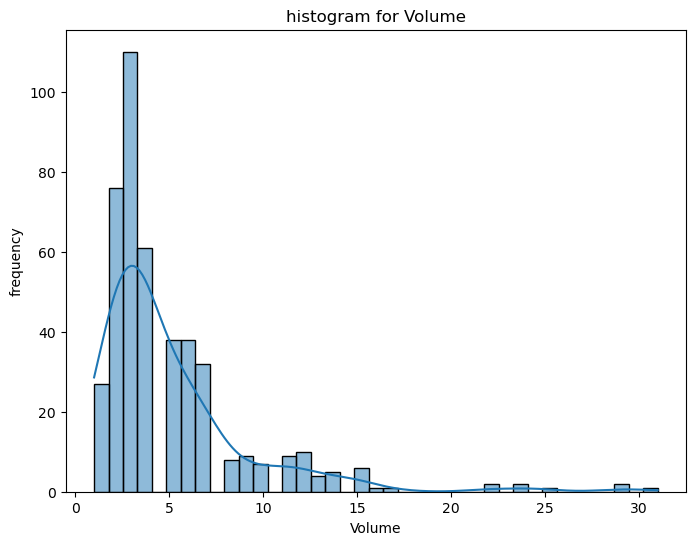

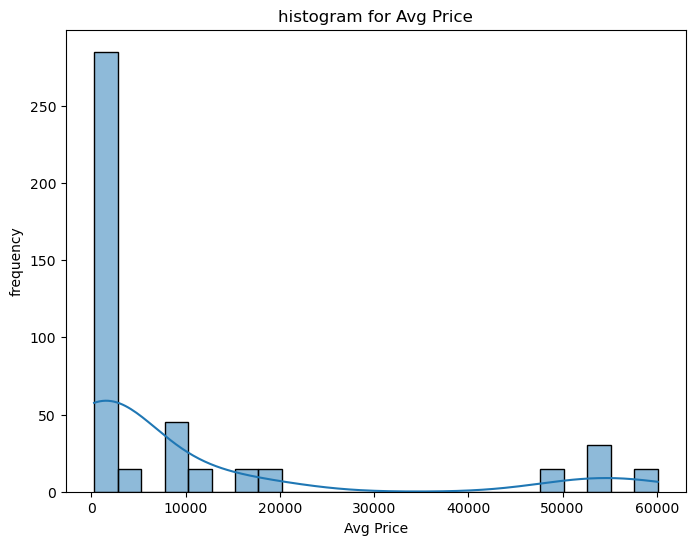

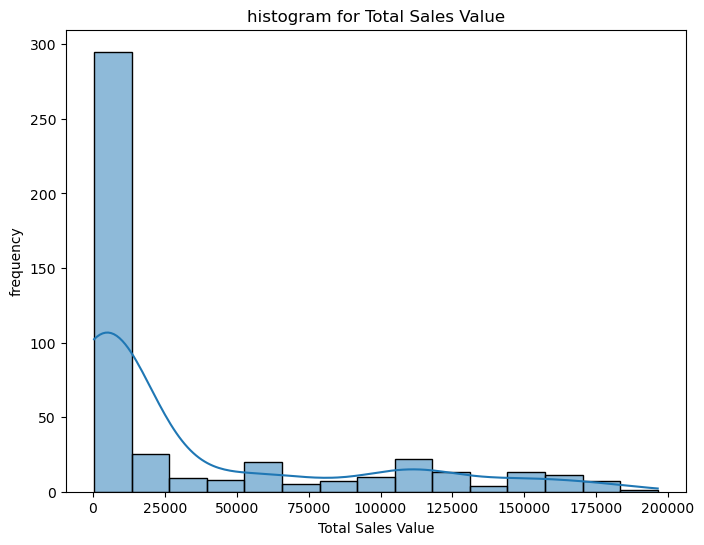

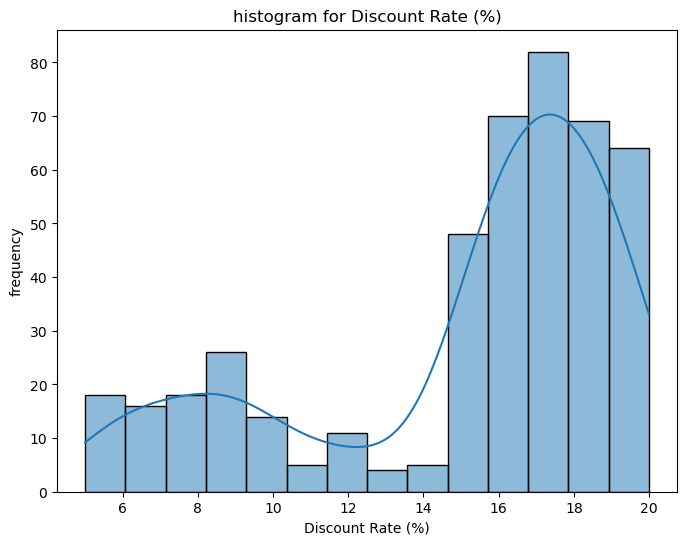

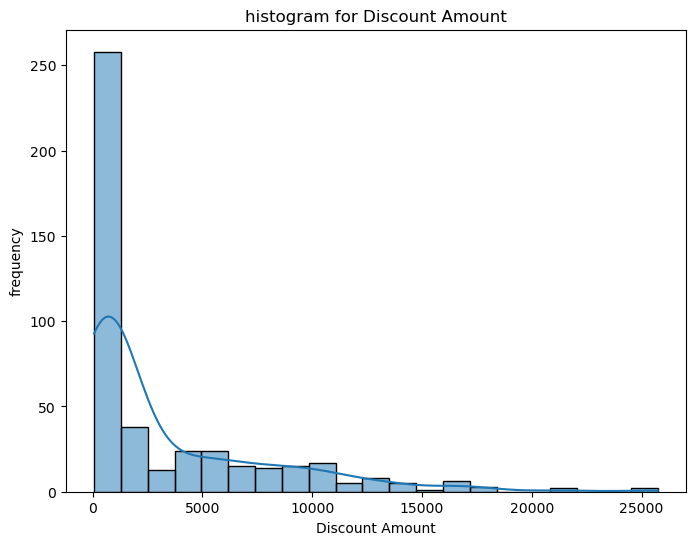

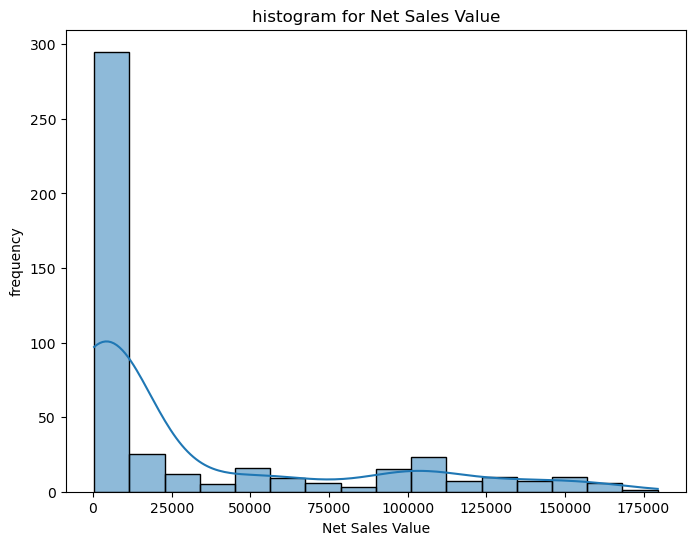

In [22]:
for col in numerical_cols:
    plt.figure(figsize=(8,6))
    sns.histplot(df[col],kde=True)
    plt.title(f'histogram for {col}')
    plt.xlabel(col)
    plt.ylabel('frequency')
    plt.show()

## Box Plots:
Create boxplots for numerical variables to identify outliers and the interquartile range.
Discuss any findings, such as extreme values or unusual distributions.


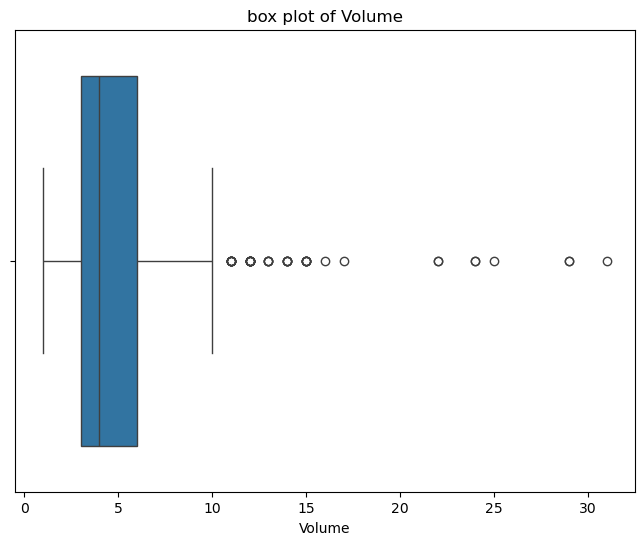

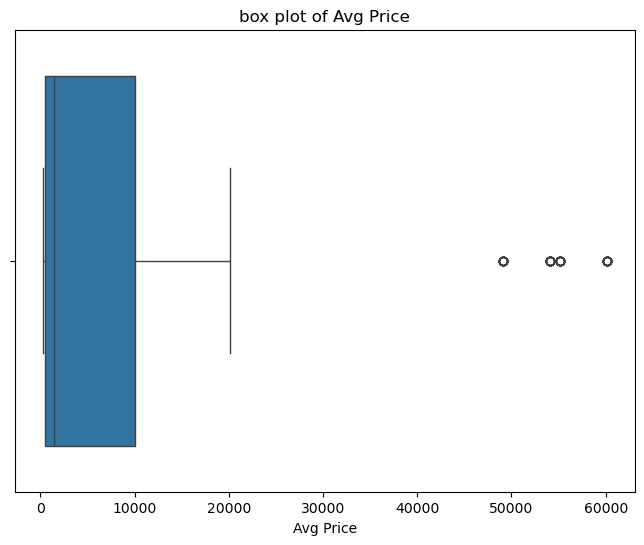

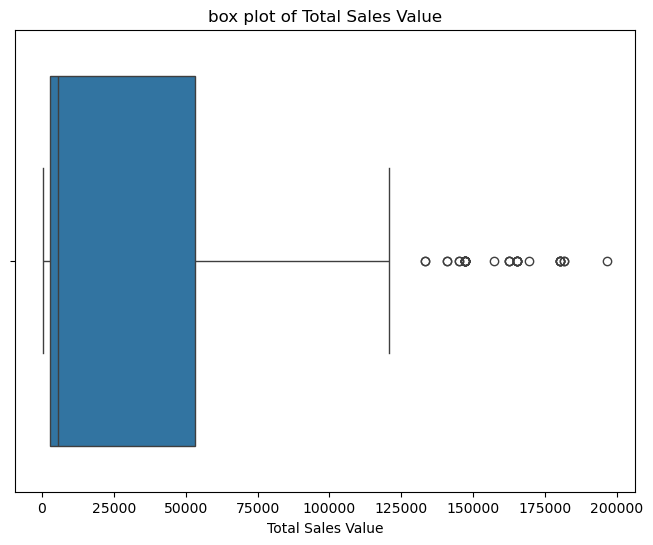

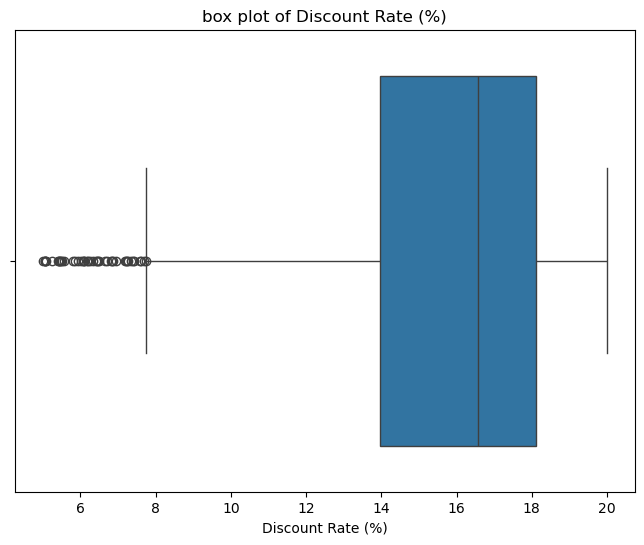

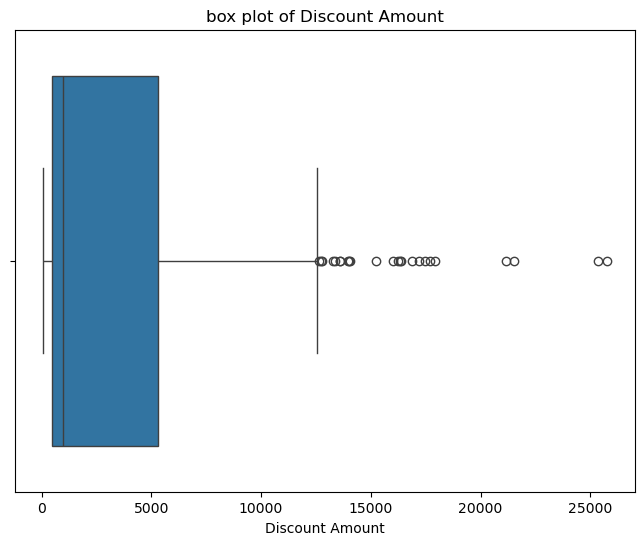

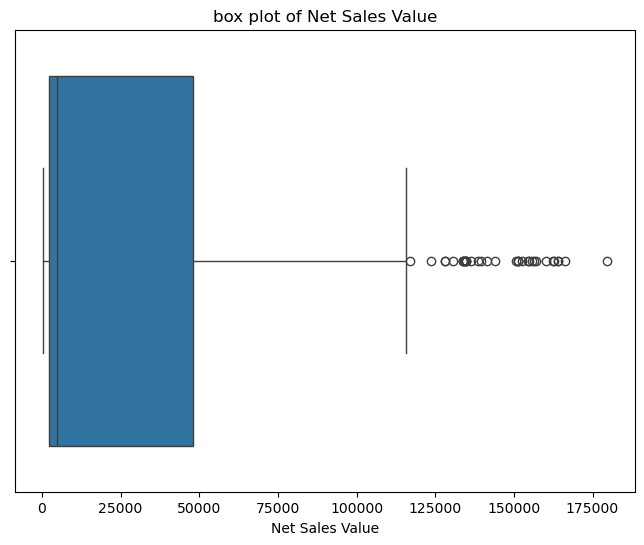

In [23]:
for col in numerical_cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])
    plt.title(f'box plot of {col}')
    plt.show()

In [32]:
df.drop_duplicates(inplace = True)

In [33]:
df.isnull().sum()

Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64

In [35]:
for col in numerical_cols:                     

    Q1 = df[col].quantile(0.25)                
    Q3 = df[col].quantile(0.75)                

    IQR = Q3 - Q1                             

    lower = Q1 - 1.5 * IQR                     
    upper = Q3 + 1.5 * IQR                     

    outliers = df[(df[col] < lower) | (df[col] > upper)]  

    print(f"{col} : {len(outliers)} outliers") 

Volume : 44 outliers
Avg Price : 60 outliers
Total Sales Value : 36 outliers
Discount Rate (%) : 45 outliers
Discount Amount : 24 outliers
Net Sales Value : 35 outliers


## findings, such as extreme values or unusual distributions
findings from boxplots:

Points outside whiskers are potential outliers.
Wider boxes indicate larger variability.
Narrow boxes indicate concentrated data.

## Bar Chart Analysis for Categorical Column:
	Identify categorical columns in the dataset.
	Create bar charts to visualize the frequency or count of each category.
	Analyze the distribution of categories and provide insights.


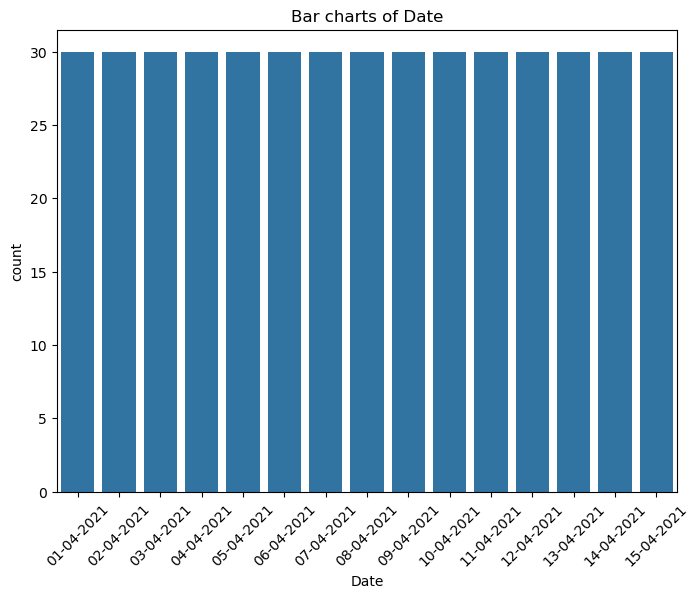

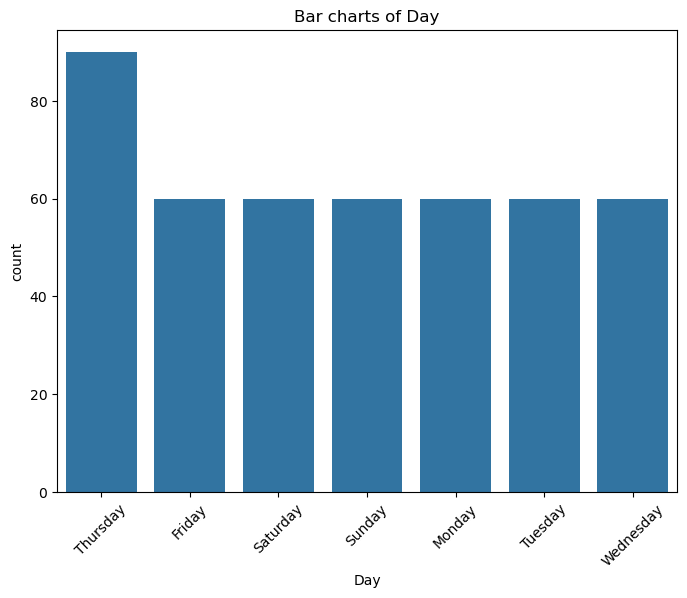

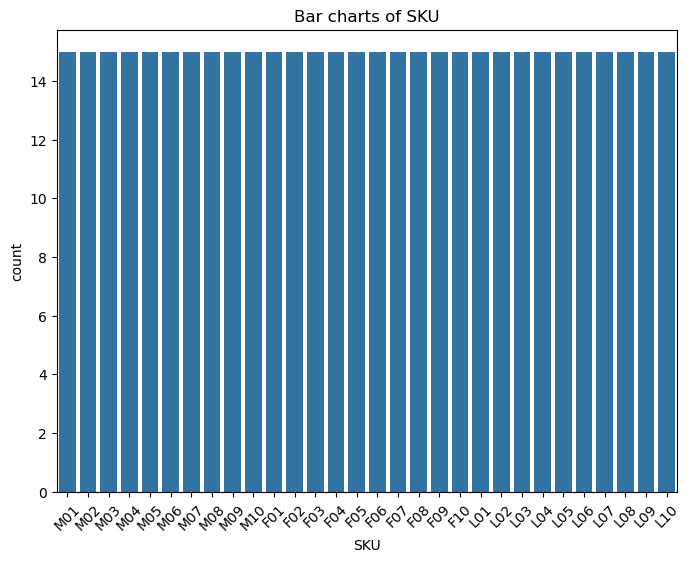

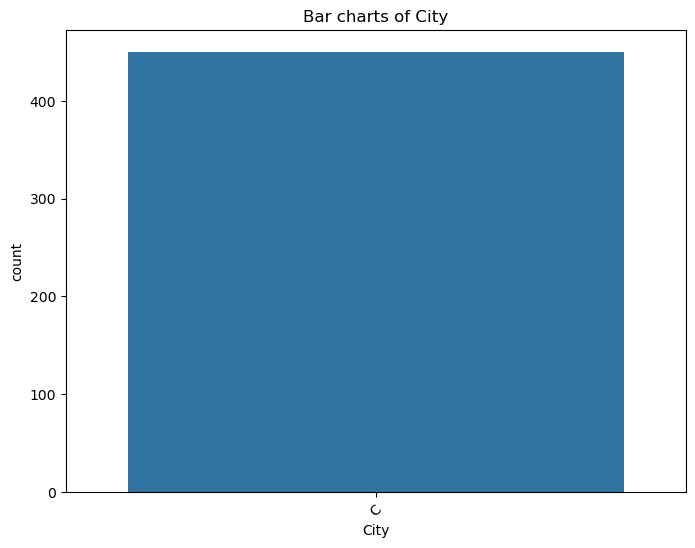

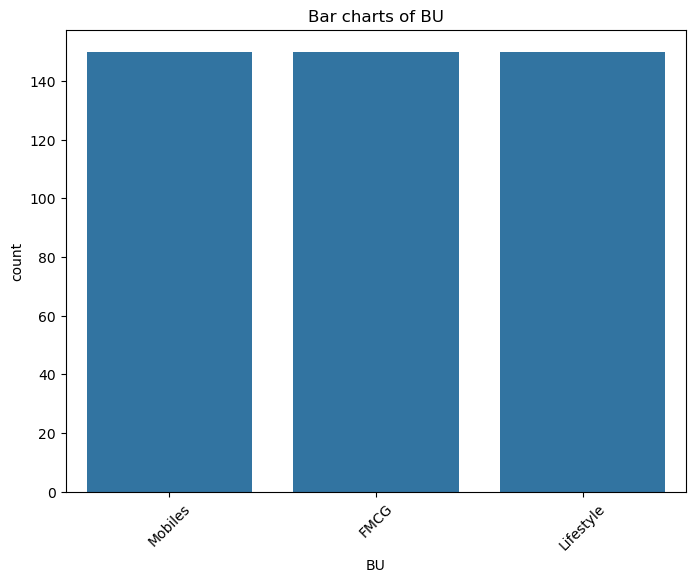

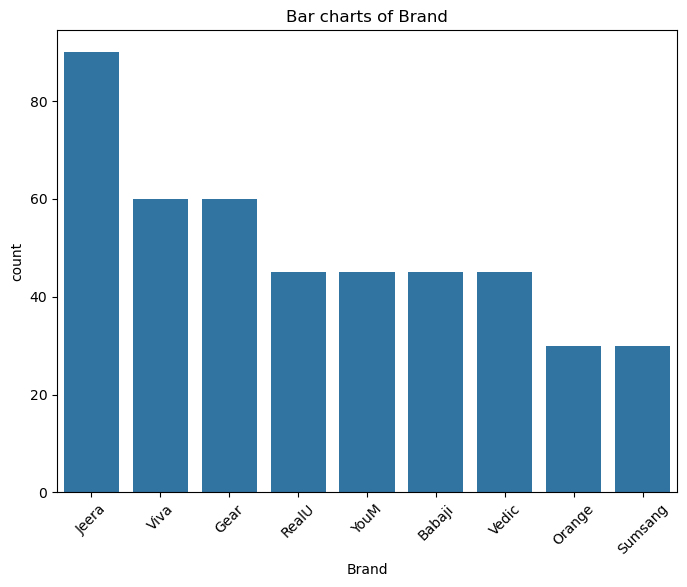

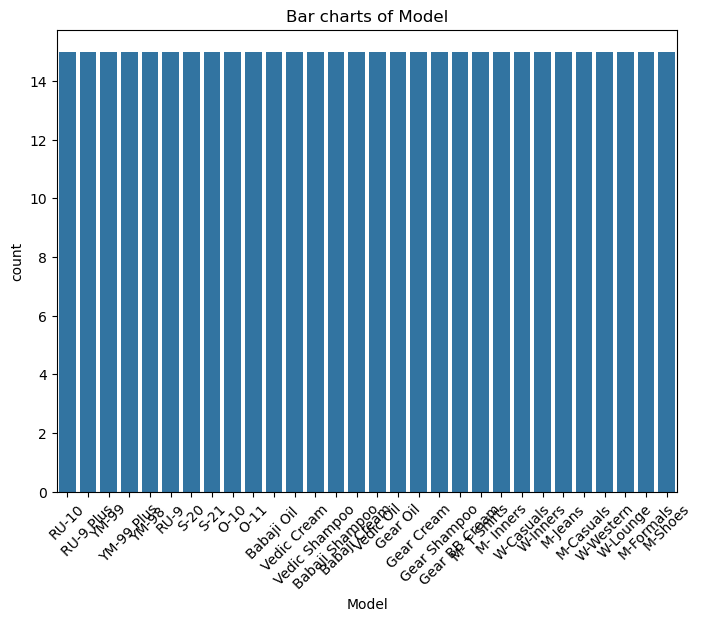

In [36]:
for col in categorical_cols:
    plt.figure(figsize=(8,6))
    sns.countplot(x=df[col],order = df[col].value_counts().index)
    plt.title(f'Bar charts of {col}')
    plt.xticks(rotation=45)
    plt.show()

    #Categories with taller bars occur more frequently.
    #Uneven distributions indicate class imbalance.

## Summarize the key findings from the descriptive analytics and data visualizations.

The dataset was analyzed using descriptive statistics and visualization techniques.
Numerical variables were examined through measures such as mean, median, mode, and standard deviation. 
Histograms revealed the distribution patterns and skewness in the data, while boxplots identified potential outliers.
Bar charts provided insights into the frequency distribution of categorical variables. 
Overall, the analysis highlighted variability in sales and discount values, presence of outliers in
certain numerical columns, and dominant categories within categorical features.
These findings will aid in effective preprocessing and further predictive analysis.